In [18]:
%matplotlib Qt

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from astropy.io import fits
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

I0000 00:00:1784641924.639216   12881 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784641924.832175   12881 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784641925.817406   12881 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Check if TensorFlow detects any GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"Success! TensorFlow detected {len(gpus)} GPU(s): {gpus}")

    # Best Practice: Enable Memory Growth
    # This prevents TensorFlow from instantly reserving all your GPU VRAM,
    # which can crash your system or prevent other apps from running.
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("Warning: No GPU detected. TensorFlow will fall back to the CPU.")

Success! TensorFlow detected 1 GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.


In [3]:
def load_and_preprocess_regression_data(data_dir, csv_path, filename_col, ba_col, ca_col):
    """
    Reads FITS files and regression targets (b/a, c/a).
    Applies global robust scaling to preserve physical scales.
    """
    df = pd.read_csv(csv_path)

    raw_images = []
    targets = []

    print("Reading FITS files and handling NaNs...")
    for index, row in df.iterrows():
        filename = row[filename_col]
        # Our targets are now two continuous values: [b/a, c/a]
        target_vals = [row[ba_col], row[ca_col]]

        filepath = os.path.join(data_dir, filename)

        with fits.open(filepath) as hdul:
            data = hdul[0].data  # Expected shape: (3, 69, 69)

        # Handle NaNs and apply individual scaling for each channel
        for i in range(3):
            channel_data = data[i, :, :]
            mean_val = np.nanmean(channel_data)
            if np.isnan(mean_val):
                mean_val = 0.0
            channel_data[np.isnan(channel_data)] = mean_val

            channel_data = channel_data / np.nanmax(np.abs(channel_data))

            data[i, :, :] = channel_data

        # Transpose to (Height, Width, Channels) -> (69, 69, 3)
        data = np.transpose(data, (1, 2, 0))
        raw_images.append(data)
        targets.append(target_vals)

    X = np.array(raw_images, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)

    return X, y

In [4]:
# --- CONFIGURATION ---
DATA_DIRECTORY = "./VELOCITY_VDISP_FLUX_MAPS"
CSV_FILE_PATH = "./files_list_and_axis.csv"
FILENAME_COLUMN_NAME = "filename"
BA_COLUMN_NAME = "b_a"        # Update with your actual column name for b/a
CA_COLUMN_NAME = "c_a"        # Update with your actual column name for c/a

In [5]:
# 1. Load Data
X, y = load_and_preprocess_regression_data(
    data_dir=DATA_DIRECTORY,
    csv_path=CSV_FILE_PATH,
    filename_col=FILENAME_COLUMN_NAME,
    ba_col=BA_COLUMN_NAME,
    ca_col=CA_COLUMN_NAME
)

Reading FITS files and handling NaNs...


In [6]:
def compute_sample_weights(y):
    """
    Calculates sample weights based on the 2D density of the targets.
    Rare (b/a, c/a) combinations will receive higher weights.
    """
    print("Calculating 2D Kernel Density for sample weighting...")

    # Transpose y for KDE: needs shape (2, num_samples)
    values = y.T

    # Calculate the density of the parameter space using Gaussian KDE
    kde = gaussian_kde(values)
    density = kde.evaluate(values)

    # Inverse density weighting: rarer points get higher weights
    # We add a small constant (epsilon) to prevent division by zero or infinite weights
    epsilon = np.percentile(density, 5) # Prevent extreme spikes for utter outliers
    weights = 1.0 / (density + epsilon)

    # Normalize weights so the mean weight is 1.0.
    # This prevents the overall learning rate from needing massive adjustment.
    weights = weights / np.mean(weights)

    return weights.astype(np.float32)

In [7]:
# 2. Split Data (No stratification needed for continuous regression)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Calculate Sample Weights for the Training Set
# This applies the "penalty" for rare parameters
train_weights = compute_sample_weights(y_train)

Calculating 2D Kernel Density for sample weighting...


In [8]:
# ==========================================
# 3. REGRESSION MODEL ARCHITECTURE
# ==========================================

def build_regression_model(input_shape=(69, 69, 3)):
    """
    Builds a CNN optimized for continuous parameter extraction.
    Ends with a Sigmoid layer to strictly bound predictions between 0 and 1.
    """
    l2_reg = tf.keras.regularizers.l2(1e-4)

    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Spatial Augmentations
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),

        # DEPTHWISE CONVOLUTION (Independent physical maps)
        tf.keras.layers.DepthwiseConv2D(
            kernel_size=(3, 3),
            depth_multiplier=8,
            activation='relu',
            padding='same',
            depthwise_regularizer=l2_reg
        ),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # MIXING & FEATURE EXTRACTION
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # We add one more Convolution block to distill features for regression
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2_reg),

        # FLATTEN & REGRESS
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2_reg),
        tf.keras.layers.Dropout(0.3),

        # OUTPUT LAYER: 2 units (b/a, c/a)
        # Activation is 'sigmoid' which mathematically forces the output
        # to always be strictly between 0.0 and 1.0.
        tf.keras.layers.Dense(2, activation='sigmoid')
    ])

    # We use Mean Squared Error (MSE) for regression.
    # Mean Absolute Error (MAE) is tracked as a secondary metric for interpretability.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model

In [9]:
# 4. Create tf.data.Datasets
batch_size = 32

# Notice we pass a tuple of THREE items here: (features, targets, weights)
# TensorFlow will automatically use the weights to scale the MSE loss!
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, train_weights))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Validation dataset does not use weights. We want pure, unweighted MSE for validation evaluation.
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 5. Build Model & Train
model = build_regression_model(input_shape=(69, 69, 3))

I0000 00:00:1784641936.050982   12881 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3660 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_mae',
        patience=150,
        restore_best_weights=True
    )

In [11]:
print("Starting training with continuous density weighting...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1500,
    callbacks=[early_stopping]
)

Starting training with continuous density weighting...
Epoch 1/1500


I0000 00:00:1784641938.733154   12988 service.cc:153] XLA service 0x76db4c034fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784641938.733174   12988 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1784641938.763630   12988 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784641938.912542   12988 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1784641938.952728   12988 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2738__.44
I0000 00:00:1784641939.870206   12988 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

 28/251 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0724 - mae: 0.1916

I0000 00:00:1784641944.443100   12988 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/251 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0443 - mae: 0.1405

I0000 00:00:1784641946.113938   12993 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2738__.44


251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - loss: 0.0342 - mae: 0.1251 - val_loss: 0.0199 - val_mae: 0.0982
Epoch 2/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0243 - mae: 0.1082 - val_loss: 0.0187 - val_mae: 0.1043
Epoch 3/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0227 - mae: 0.1056 - val_loss: 0.0178 - val_mae: 0.1016
Epoch 4/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0218 - mae: 0.1039 - val_loss: 0.0157 - val_mae: 0.0896
Epoch 5/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0213 - mae: 0.1034 - val_loss: 0.0156 - val_mae: 0.0921
Epoch 6/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0208 - mae: 0.1036 - val_loss: 0.0176 - val_mae: 0.1057
Epoch 7/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0204 - mae: 0.1019 - val_loss: 0.0155 - val_mae: 0.0938
Epoch 8/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0201 - mae: 0.1017 - val_loss: 0.0195 - val_mae: 0.1152
Epoch 9/1500
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/st

In [27]:
# ==========================================
# 5. EVALUATION AND PLOTTING
# ==========================================
print("\n--- Model Evaluation ---")

# Predict on validation data
y_pred = model.predict(val_dataset)

# Plot True vs Predicted for b/a and c/a
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot b/a
axes[0].scatter(y_val[:, 0], y_pred[:, 0], alpha=0.5, c='blue')
axes[0].plot([0, 1], [0, 1], 'r--') # Perfect prediction line
axes[0].set_title("Target: b/a")
axes[0].set_xlabel("True b/a")
axes[0].set_ylabel("Predicted b/a")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Plot c/a
axes[1].scatter(y_val[:, 1], y_pred[:, 1], alpha=0.5, c='green')
axes[1].plot([0, 1], [0, 1], 'r--') # Perfect prediction line
axes[1].set_title("Target: c/a")
axes[1].set_xlabel("True c/a")
axes[1].set_ylabel("Predicted c/a")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


--- Model Evaluation ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [16]:
def plot_training_history(history):
    """
    Plots the training and validation accuracy and loss curves.
    """
    acc = history.history['mae']
    val_acc = history.history['val_mae']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

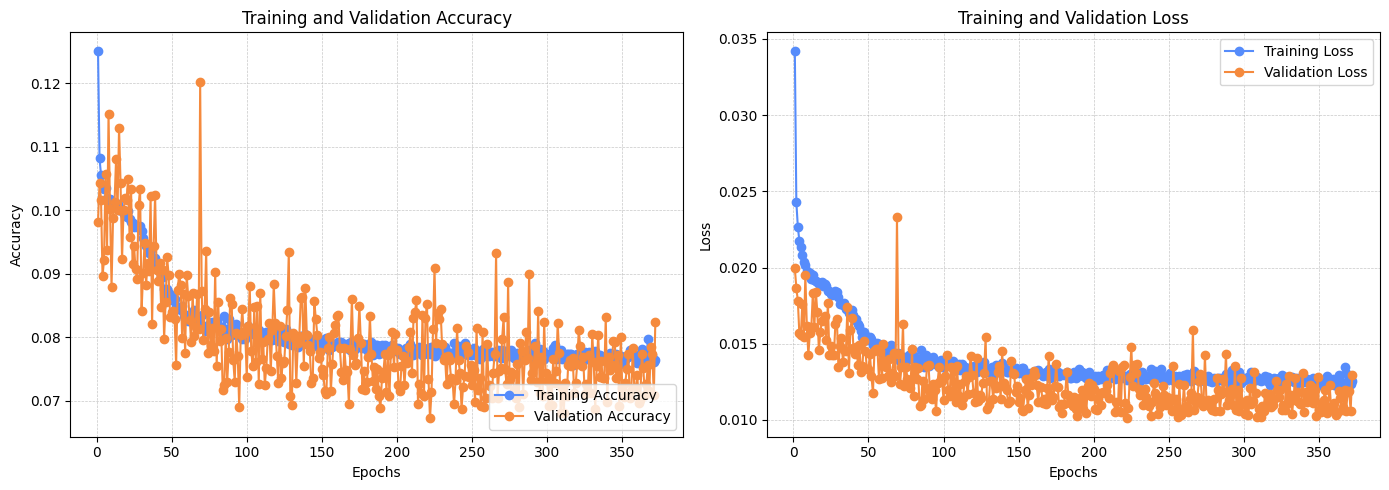

In [17]:
plot_training_history(history)

In [25]:
results = pd.DataFrame({'true_b_a': y_val[:, 0], 'pred_b_a': y_pred[:, 0], 'true_c_a': y_val[:, 1], 'pred_c_a': y_pred[:, 1]})

In [28]:
results.to_csv('predictions.csv', index=False, header=True)

In [29]:
results['pred_c_a'] > results['pred_b_a']

0       False
1       False
2       False
3       False
4       False
        ...  
2002    False
2003    False
2004    False
2005    False
2006    False
Length: 2007, dtype: bool